<h1><center>PENERAPAN OLAP</center>
</h1>

<h3>
NAMA: RAFAEL HARTONO    

NIM: 24031554166

KELAS: 2024C

MATA KULIAH: DATA WAREHOUSE
</h3>



In [ ]:
import yfinance as yf
import atoti as tt
import pandas as pd
from datetime import datetime

# tickers = [
#     'GC=F', 'SI=F', 'CL=F', 'NG=F', 'HG=F', # Komoditas (Gold, Silver, Oil, Gas, Copper)
#     'BTC-USD',                              # Aset Kripto
#     'NVDA', 'AAPL', 'MSFT', 'TSLA', 'GOOGL',# Saham Teknologi (NVidia, Apple, Microsoft, Tesla, Alphabet)
#     'BBCA.JK', 'BBRI.JK', 'TLKM.JK', 'ASII.JK', # Saham Indonesia (BBCA, BBRI, TLKM, ASII)
#     '^GSPC', '^JKSE', '^IXIC', 'IDR=X', '^TNX'  # Indeks dan Mata Uang (S&P 500, IDX Composite, NASDAQ, IDR/USD, US Treasury Yield)
# ]

# print("Mengumpulkan data dari Yahoo Finance")


# data = yf.download(tickers, start="1927-01-01")['Close']

# df = data.stack().reset_index()
# df.columns = ['Date', 'Symbol', 'Price']
# df['Date'] = pd.to_datetime(df['Date'])

# df.to_feather('20_market_data.feather')

# print(f"Berhasil menarik {len(df)} baris data")
# df

In [ ]:
df = pd.read_feather('20_market_data.feather')
print(f"Berhasil menarik {len(df)} baris data")
df

Berhasil menarik 166061 baris data


,Date,Symbol,Price
0,1927-12-30,^GSPC,17.660000
1,1928-01-03,^GSPC,17.760000
2,1928-01-04,^GSPC,17.719999
3,1928-01-05,^GSPC,17.549999
4,1928-01-06,^GSPC,17.660000
...,...,...,...
166056,2026-03-16,IDR=X,16990.000000
166057,2026-03-16,NG=F,3.122000
166058,2026-03-16,SI=F,80.364998
166059,2026-03-16,TLKM.JK,2910.000000


In [ ]:
asset_mapping = {
    'GC=F': 'Komoditas', 'SI=F': 'Komoditas', 'CL=F': 'Komoditas', 'NG=F': 'Komoditas', 'HG=F': 'Komoditas',
    'BTC-USD': 'Kripto',
    'NVDA': 'Saham Teknologi', 'AAPL': 'Saham Teknologi', 'MSFT': 'Saham Teknologi', 'TSLA': 'Saham Teknologi', 'GOOGL': 'Saham Teknologi',
    'BBCA.JK': 'Saham Indonesia', 'BBRI.JK': 'Saham Indonesia', 'TLKM.JK': 'Saham Indonesia', 'ASII.JK': 'Saham Indonesia',
    '^GSPC': 'Indeks & Mata Uang', '^JKSE': 'Indeks & Mata Uang', '^IXIC': 'Indeks & Mata Uang', 'IDR=X': 'Indeks & Mata Uang', '^TNX': 'Indeks & Mata Uang'
}

df['Kategori'] = df['Symbol'].map(asset_mapping)

df

,Date,Symbol,Price,Kategori
0,1927-12-30,^GSPC,17.660000,Indeks & Mata Uang
1,1928-01-03,^GSPC,17.760000,Indeks & Mata Uang
2,1928-01-04,^GSPC,17.719999,Indeks & Mata Uang
3,1928-01-05,^GSPC,17.549999,Indeks & Mata Uang
4,1928-01-06,^GSPC,17.660000,Indeks & Mata Uang
...,...,...,...,...
166056,2026-03-16,IDR=X,16990.000000,Indeks & Mata Uang
166057,2026-03-16,NG=F,3.122000,Komoditas
166058,2026-03-16,SI=F,80.364998,Komoditas
166059,2026-03-16,TLKM.JK,2910.000000,Saham Indonesia


In [ ]:

# 2. Mulai Session Atoti
session = tt.Session.start()
macro_table = session.read_pandas(df, table_name="MarketData", keys=["Date", "Symbol"])



In [ ]:
macro_table.head()

,,Price,Kategori
Date,Symbol,,
1927-12-30,^GSPC,17.66,Indeks & Mata Uang
1928-01-11,^GSPC,17.35,Indeks & Mata Uang
1928-02-06,^GSPC,17.450001,Indeks & Mata Uang
1928-02-07,^GSPC,17.440001,Indeks & Mata Uang
1928-02-27,^GSPC,17.110001,Indeks & Mata Uang


In [ ]:
cube = session.create_cube(macro_table)
h = cube.hierarchies
l = cube.levels
m = cube.measures


# Membuat Hierarchy Waktu yang cerdas (Tahun > Bulan > Hari)
cube.create_date_hierarchy(
    "Periode Analisis", 
    column=macro_table["Date"],
    levels={
        "Tahun": "yyyy",
        "Bulan": "MMMM",
        "Hari": "dd"
    }
)

# Opsional: Hapus hierarchy 'Date' bawaan yang flat agar tidak bingung
del h["Date"]


print('Hierarchies:', list(h.keys()))
print('Levels:', list(l.keys()))
print('Measures:', list(m.keys()))

Hierarchies: [('MarketData', 'Kategori'), ('MarketData', 'Symbol'), ('MarketData', 'Periode Analisis')]
Levels: [('MarketData', 'Kategori', 'Kategori'), ('MarketData', 'Symbol', 'Symbol'), ('MarketData', 'Periode Analisis', 'Tahun'), ('MarketData', 'Periode Analisis', 'Bulan'), ('MarketData', 'Periode Analisis', 'Hari')]
Measures: ['Price.MEAN', 'Price.SUM', 'contributors.COUNT', 'update.TIMESTAMP']


HARGA ASLI

In [ ]:
m["Price.VALUE"] = tt.agg.single_value(macro_table["Price"])


cube.query(
            m['Price.VALUE'], 
            levels=[l['Symbol'], l['Hari']])

Price.VALUE
Symbol Tahun Bulan    Hari            
AAPL   1980  December 12           .10
                      15           .09
                      16           .09
                      17           .09
                      18           .09
...                                ...
^TNX   2026  March    09          4.14
                      10          4.14
                      11          4.21
                      12          4.27
                      13          4.28

[166061 rows x 1 columns]

In [ ]:
m["Price H-1"] = tt.shift(
                        m["Price.VALUE"], 
                        h["Periode Analisis"],
                        offset=-1,
                        mode="measure")

cube.query(
            m['Price.VALUE'], 
            m['Price H-1'], 
            levels=[l['Symbol'], l['Hari']])

Price.VALUE Price H-1
Symbol Tahun Bulan    Hari                      
AAPL   1980  December 12           .10          
                      15           .09       .10
                      16           .09       .09
                      17           .09       .09
                      18           .09       .09
...                                ...       ...
^TNX   2026  March    09          4.14      4.13
                      10          4.14      4.14
                      11          4.21      4.14
                      12          4.27      4.21
                      13          4.28      4.27

[166061 rows x 2 columns]

In [ ]:
# PERBAIKAN: Gunakan parameter 'level' dan arahkan ke l["Hari"]
# l["Hari"] adalah level terbawah dari hierarchy "Periode Analisis" kamu
cumulative_scope = tt.CumulativeScope(
                                    level=l["Hari"],
                                    )

# Sekarang hitung ulang Cumulative Return
m["Cumulative Return"] = tt.agg.prod(
    1 + m["Daily Return"], 
    scope=cumulative_scope
) - 1

m["Cumulative Return"].formatter = "DOUBLE[0.00%]"

cube.query(
            m["Cumulative Return"], 
            levels=[l["Symbol"], l["Hari"]],
            )

Cumulative Return
Symbol Tahun Bulan    Hari                  
AAPL   1980  December 12               0.00%
                      15              -5.22%
                      16             -12.17%
                      17             -10.00%
                      18              -7.39%
...                                      ...
^TNX   2026  March    09               7.15%
                      10               7.15%
                      11               9.02%
                      12              10.70%
                      13              11.01%

[166061 rows x 1 columns]

In [ ]:
m["Daily Return"] = ((m["Price.VALUE"] - m["Price H-1"]) / m["Price H-1"])
m["Daily Return"].formatter = "DOUBLE[0.00%]"
cube.query(m['Daily Return'], levels=[l['Symbol'], l['Hari']])

Daily Return
Symbol Tahun Bulan    Hari             
AAPL   1980  December 15         -5.22%
                      16         -7.34%
                      17          2.48%
                      18          2.90%
                      19          6.10%
...                                 ...
^TNX   2026  March    09          0.07%
                      10          0.00%
                      11          1.74%
                      12          1.54%
                      13          0.28%

[166041 rows x 1 columns]

In [ ]:

m['SMA_20'] = tt.agg.mean(
    m["Price.VALUE"], 
    scope=tt.CumulativeScope(
        level=l["Hari"], 
        window=range(-19, 1) 
    )
)

m['SMA_20'].formatter = "DOUBLE[0.00]"

cube.query(
        m['SMA_20'], 
        m['Price.VALUE'],           
        levels=[l['Symbol'], l['Hari']])

SMA_20 Price.VALUE
Symbol Tahun Bulan    Hari                   
AAPL   1980  December 12     0.10         .10
                      15     0.09         .09
                      16     0.09         .09
                      17     0.09         .09
                      18     0.09         .09
...                           ...         ...
^TNX   2026  March    09     4.18        4.14
                      10     4.18        4.14
                      11     4.19        4.21
                      12     4.19        4.27
                      13     4.20        4.28

[166061 rows x 2 columns]

In [ ]:

m["Volatility_20"] = tt.agg.std(
    m["Daily Return"],
    scope=tt.CumulativeScope(
        level=l["Hari"], 
        window=range(-19, 1)
    ) 
)

m["Volatility_20"].formatter = "DOUBLE[0.00%]"
cube.query(
        m["Volatility_20"], 
        levels=[l["Symbol"], l["Hari"]])

Volatility_20
Symbol Tahun Bulan    Hari              
AAPL   1980  December 15           1.50%
                      16           5.16%
                      17           5.25%
                      18           5.76%
                      19           5.55%
...                                  ...
^TNX   2026  March    09           1.27%
                      10           1.33%
                      11           1.36%
                      12           1.35%
                      13           1.38%

[166041 rows x 1 columns]

In [ ]:
cube.query(m['Price.MEAN'], levels=[l['Symbol'], l['Bulan']])

Price.MEAN
Symbol Tahun Bulan               
AAPL   1980  December         .10
       1981  April            .09
             August           .08
             December         .07
             February         .09
...                           ...
^TNX   2025  October         4.05
             September       4.11
       2026  February        4.12
             January         4.21
             March           4.15

[7914 rows x 1 columns]

In [ ]:

cube.query(m['Price.MEAN'], levels=[l['Symbol'], l['Tahun']])

Price.MEAN
Symbol Tahun           
AAPL   1980         .10
       1981         .08
       1982         .07
       1983         .13
       1984         .09
...                 ...
^TNX   2022        2.96
       2023        3.97
       2024        4.21
       2025        4.29
       2026        4.16

[685 rows x 1 columns]

1. Berapa tahun waktu yang dibutuhkan S&P 500 untuk pulih ke titik nol setelah hancur di tahun 1929?

In [ ]:

m["Price"] = tt.agg.mean(macro_table["Price"])

# 2. Safe Price: Jangan dikunci di angka 4! 
# Cukup cek apakah harganya ada dan tidak nol.
m["Safe Price"] = tt.where(m["Price"] > 0, m["Price"], None)

# 3. Hitung Safe Rolling Max dengan partitioning Symbol (Sangat Penting!)
m["Safe Rolling Max"] = tt.agg.max(
    m["Safe Price"], 
    scope=tt.CumulativeScope(
        level=l["Hari"], 
        partitioning=l["Symbol"] # Agar harga S&P 500 tidak merusak Drawdown BBCA
    )
)

# 4. Hitung Safe Drawdown dengan proteksi agar tidak jadi -100% saat datanya kosong
m["Safe Drawdown"] = tt.where(
    m["Safe Price"] != None,
    (m["Safe Price"] / m["Safe Rolling Max"]) - 1,
    None
)
m["Safe Drawdown"].formatter = "DOUBLE[0.00%]"

In [ ]:

# 3. Measure untuk melihat status Breakeven

m["Is Breakeven"] = tt.where(m["Safe Drawdown"] >= 0.00, "SUDAH PULIH", "BELUM PULIH")

# Periode 1929 - 1955 (Pasar butuh waktu sangat lama untuk pulih)
query_1929 = cube.query(
    m["Cumulative Return"],
    m["Safe Drawdown"],
    m["Is Breakeven"],
    levels=[l["Symbol"], l["Hari"]],
    filter=(
        (l["Symbol"].isin("^GSPC")) & 
        (l["Tahun"] >= "1927") & 
        (l["Tahun"] <= "1955")
    )
)

print("Analisis Krisis 1929:")
print(query_1929)

Analisis Krisis 1929:
                            Cumulative Return Safe Drawdown Is Breakeven
Symbol Tahun Bulan     Hari                                             
^GSPC  1927  December  30               0.00%      -100.00%  BELUM PULIH
       1928  April     02               7.08%      -100.00%  BELUM PULIH
                       03               7.70%      -100.00%  BELUM PULIH
                       04               7.53%      -100.00%  BELUM PULIH
                       05               8.89%      -100.00%  BELUM PULIH
...                                       ...           ...          ...
       1955  September 26             141.28%      -100.00%  BELUM PULIH
                       27             146.77%      -100.00%  BELUM PULIH
                       28             150.91%      -100.00%  BELUM PULIH
                       29             149.32%      -100.00%  BELUM PULIH
                       30             147.28%      -100.00%  BELUM PULIH

[6999 rows x 3 columns]


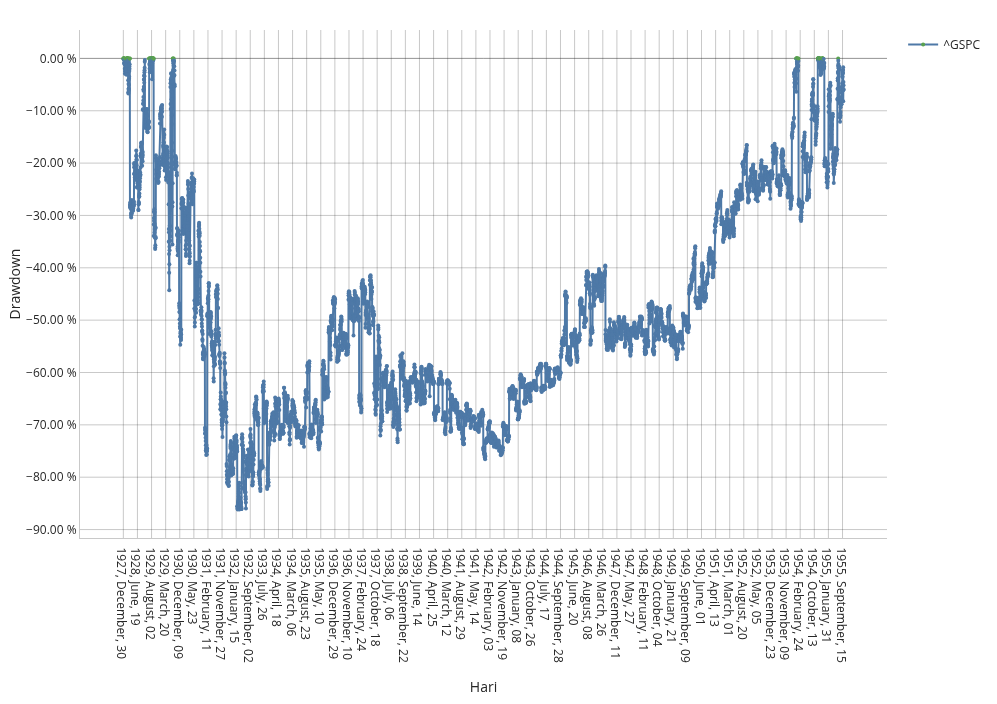

In [ ]:
bca_first = df[df['Symbol'] == 'BBCA.JK'].iloc[0]
print("\nData pertama untuk BBCA.JK:")
print(bca_first)


Data pertama untuk BBCA.JK:
Date        2004-06-08 00:00:00
Symbol                  BBCA.JK
Price                 99.041359
Kategori        Saham Indonesia
Name: 59941, dtype: object


2. Bagaimana daya tahan saham Indonesia (BBCA) dibandingkan pasar global (S&P 500) saat krisis Subprime Mortgage 2008??

In [ ]:
query_2005 = cube.query(
    m["Cumulative Return"],
    m["Safe Drawdown"],
    m["Is Breakeven"],
    levels=[l["Symbol"], l["Hari"]],
    filter=(
        (l["Symbol"].isin("BBCA.JK", "^GSPC")) & 
        (l["Tahun"] >= "2005") & 
        (l["Tahun"] <= "2010")
    )
)

print("Analisis Krisis 2005:")
print(query_2005)

Analisis Krisis 2005:
                             Cumulative Return Safe Drawdown Is Breakeven
Symbol  Tahun Bulan     Hari                                             
BBCA.JK 2005  April     01              87.25%      -100.00%  BELUM PULIH
                        04              90.01%      -100.00%  BELUM PULIH
                        05              88.63%      -100.00%  BELUM PULIH
                        06              90.01%      -100.00%  BELUM PULIH
                        07              88.63%      -100.00%  BELUM PULIH
...                                        ...           ...          ...
^GSPC   2010  September 24            6404.36%      -100.00%  BELUM PULIH
                        27            6367.50%      -100.00%  BELUM PULIH
                        28            6398.87%      -100.00%  BELUM PULIH
                        29            6382.05%      -100.00%  BELUM PULIH
                        30            6362.06%      -100.00%  BELUM PULIH

[2992 rows x 3 

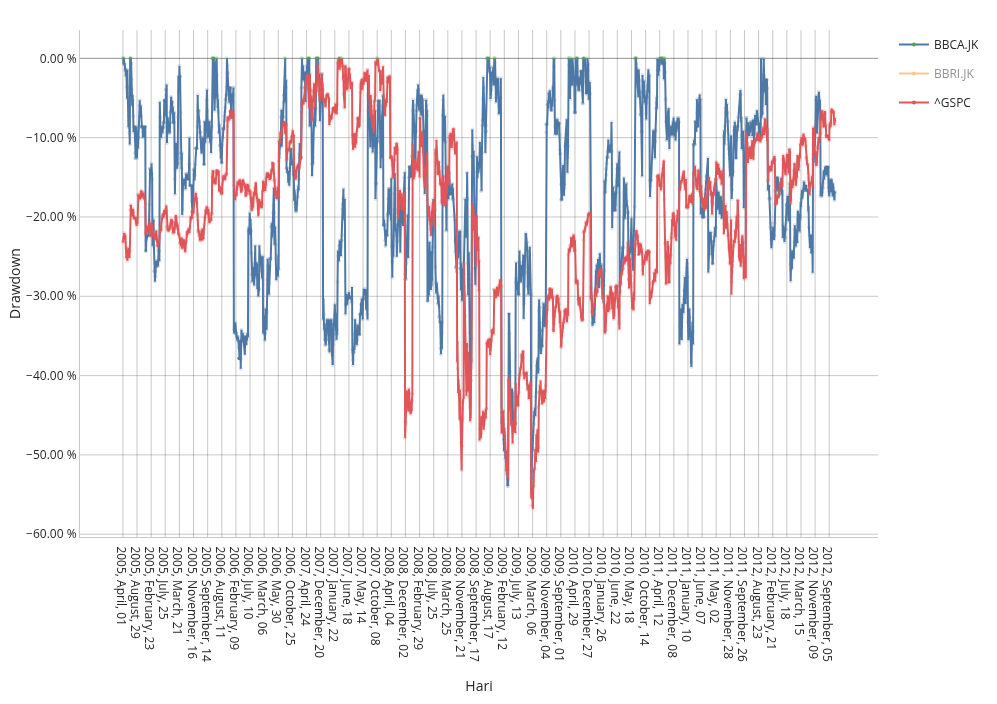

3. Di antara semua kategori, mana yang paling tahan banting dan paling cepat "terbang" saat pandemi COVID-19?

In [ ]:
query_2019 = cube.query(
    m["Cumulative Return"],
    m["Safe Drawdown"],
    m["Is Breakeven"],
    levels=[l["Kategori"], l["Hari"]],
    filter=(
        (l["Symbol"].isin("BTC-USD","GC=F","NVDA","BBCA.JK")) & 
        (l["Tahun"] >= "2019") & 
        (l["Tahun"] <= "2023")
    )
)

print("Analisis Krisis 2019:")
print(query_2019)

Analisis Krisis 2019:
                                     Cumulative Return Safe Drawdown  \
Kategori        Tahun Bulan     Hari                                   
Komoditas       2019  April     01             370.39%      -100.00%   
                                02             370.97%      -100.00%   
                                03             370.94%      -100.00%   
                                04             370.61%      -100.00%   
                                05             371.12%      -100.00%   
...                                                ...           ...   
Saham Teknologi 2023  September 25          107660.26%      -100.00%   
                                26          106866.54%      -100.00%   
                                27          108288.12%      -100.00%   
                                28          109873.06%      -100.00%   
                                29          110919.48%      -100.00%   

                                     Is B

In [ ]:
# Analisis Krisis 2019 (Hanya muncul jika ke-4 simbol punya data di hari itu)
query_2019 = cube.query(
    m["Cumulative Return"],
    m["Safe Drawdown"],
    m["Is Breakeven"],
    levels=[l["Kategori"], l["Hari"]],
    filter=(
        (l["Symbol"].isin("BTC-USD", "GC=F", "NVDA", "BBCA.JK")) & 
        (l["Tahun"] >= "2019") & 
        (l["Tahun"] <= "2023")
    ),
    include_empty_rows=False # Ini akan membuang tanggal yang 'Safe Price'-nya None
)

print("Analisis Krisis 2019:")
query_2019.head(20)

Analisis Krisis 2019:


Cumulative Return  Safe Drawdown Is Breakeven
Kategori  Tahun Bulan Hari                                               
Komoditas 2019  April 01             3.703907           -1.0  BELUM PULIH
                      02             3.709748           -1.0  BELUM PULIH
                      03             3.709383           -1.0  BELUM PULIH
                      04             3.706097           -1.0  BELUM PULIH
                      05             3.711209           -1.0  BELUM PULIH
                      08              3.73567           -1.0  BELUM PULIH
                      09             3.759036           -1.0  BELUM PULIH
                      10             3.779482           -1.0  BELUM PULIH
                      11             3.704637           -1.0  BELUM PULIH
                      12             3.711939           -1.0  BELUM PULIH
                      15             3.698065           -1.0  BELUM PULIH
                      16             3.646221           -1.0  BELUM PULIH
                      17             3.644761           -1.0  BELUM PULIH
                      18             3.643666           -1.0  BELUM PULIH
                      22             3.649507           -1.0  BELUM PULIH
                      23             3.634173           -1.0  BELUM PULIH
                      24             3.656809           -1.0  BELUM PULIH
                      25             3.657905           -1.0  BELUM PULIH
                      26             3.691128           -1.0  BELUM PULIH
                      29             3.668127           -1.0  BELUM PULIH

In [ ]:
# 1. Filter data hanya untuk kategori Komoditas di bulan November 2023
november_data = df[
    (df['Kategori'] == 'Komoditas') & 
    (df['Date'] >= '2023-11-01') & 
    (df['Date'] <= '2023-11-30')
].copy()

# 2. Cari simbol yang harganya 0 atau NaN (penyebab -100%)
missing_values = november_data[
    (november_data['Price'] <= 0) | (november_data['Price'].isna())
]

# 3. Hitung jumlah hari aktif per simbol (untuk melihat siapa yang berhenti di tengah jalan)
count_days = november_data.groupby('Symbol')['Date'].count()

print("--- Simbol dengan Harga Error (0 atau NaN) ---")
print(missing_values[['Date', 'Symbol', 'Price']])

print("\n--- Jumlah Hari Perdagangan di November 2023 ---")
print(count_days)

--- Simbol dengan Harga Error (0 atau NaN) ---
Empty DataFrame
Columns: [Date, Symbol, Price]
Index: []

--- Jumlah Hari Perdagangan di November 2023 ---
Symbol
CL=F    21
GC=F    21
HG=F    22
NG=F    22
SI=F    21
Name: Date, dtype: int64


In [ ]:
# Ini akan mencetak link dashboard kamu
print(f"Buka dashboard di sini: {session.url}")

# Atau biarkan Atoti membukanya secara otomatis di browser default
session.link

Buka dashboard di sini: http://localhost:35059


http://localhost:35059

Ini adalah persiapan presentasi pamungkasmu, Rafael! Menggunakan data hampir satu abad (1927–2026) di Atoti bukan sekadar tugas teknis, melainkan pembuktian bahwa kamu bisa membaca sejarah ekonomi melalui kacamata *Data Warehouse*.

Mari kita jawab dulu pertanyaan fundamental sejarah ekonominya sebagai fondasi presentasimu:

### Konteks Sejarah Krisis (Bahan Pembuka Presentasi)

* **Krisis Terparah di Indonesia (Krisis Nasional & Asia):** **Tahun 1997–1998**. Dimulai dari pecahnya gelembung properti di Thailand (Baht), krisis ini menular ke Indonesia dan menghancurkan nilai tukar Rupiah dari Rp2.500 ke atas Rp15.000 per USD. Ini adalah krisis finansial sekaligus krisis politik (lengsernya Orde Baru).
* **Krisis Global Terparah:** ***The Great Depression* (1929–1939)**. Dipicu oleh runtuhnya bursa saham Wall Street. Butuh waktu sekitar 25 tahun bagi indeks saham AS untuk kembali ke titik puncaknya. Krisis global modern lainnya adalah **Global Financial Crisis (GFC) 2008** akibat kredit macet perumahan di AS (*Subprime Mortgage*).
* **Apakah COVID-19 (2020) itu Krisis Global?** **Sangat Global.** Ini adalah "Krisis Likuiditas" di mana semua aset (saham, emas, bahkan kripto) *crash* secara bersamaan karena kepanikan massal (*Dash for Cash*). Uniknya, pemulihannya sangat cepat (berbentuk V-Shape) karena bank sentral dunia mencetak uang besar-besaran.

---

Berikut adalah 5 *Study Case* teknis dan mendalam yang akan membuat dosenmu terpukau:

### 1. The Great Depression vs. Krisis 2008 (Time-to-Recovery Analysis)

* **Pertanyaan:** Berapa lama waktu yang dibutuhkan pasar saham global untuk pulih (*breakeven*) dari kehancuran 1929 dibandingkan krisis 2008, dan apakah Emas benar-benar berfungsi sebagai penyelamat?
* **Data (Simbol):** `^GSPC` (S&P 500 mewakili pasar global) dan `GC=F` (Emas).
* **Periode:** 1929–1955 vs 2008–2014.
* **Visualisasi:** *Line Chart* (Sumbu X: Tanggal, Sumbu Y: Cumulative Return, Split: Symbol).
* **Kenapa Pakai Simbol Ini?** `^GSPC` memiliki data historis tertua dan mewakili ekonomi terbesar dunia. `GC=F` adalah aset *Safe Haven* (tempat berlindung) paling tua dalam sejarah manusia.
* **Insight:** Kamu bisa menunjukkan bahwa di 1929, investor butuh waktu 25 tahun untuk balik modal di saham, sedangkan di 2008 hanya butuh 5 tahun. Kamu juga bisa membuktikan apakah harga Emas benar-benar naik saat S&P 500 hancur.
* **Teknis Atoti (Maximum Drawdown):**
Di Data Warehouse, kita mencari titik terendah dari sebuah krisis.
```python
# 1. Cari harga tertinggi kumulatif sejauh ini
m["Rolling Max Price"] = tt.agg.max(m["Price.VALUE"], scope=tt.CumulativeScope(level=l["Hari"]))

# 2. Hitung persentase penurunannya
m["Drawdown"] = (m["Price.VALUE"] / m["Rolling Max Price"]) - 1
m["Drawdown"].formatter = "DOUBLE[0.00%]"

```



### 2. Efek Domino Krismon 1998 (National Macro-Shock)

* **Pertanyaan:** Seberapa parah *lagging effect* (efek tunda) antara hancurnya nilai tukar Rupiah terhadap kehancuran indeks saham dan sektor perbankan Indonesia di tahun 1998?
* **Data (Simbol):** `IDR=X` (USD/IDR), `^JKSE` (IHSG), `ASII.JK` (Astra - proksi sektor riil) atau `BBCA.JK` (jika datanya tersedia di 1998).
* **Periode:** 1997–2000.
* **Visualisasi:** *Dual Axis Chart* (Kiri: Harga IDR=X, Kanan: Harga IHSG).
* **Kenapa Pakai Simbol Ini?** Pelemahan mata uang (`IDR=X`) adalah akar masalah krisis '98 karena banyak perusahaan gagal bayar utang dolar. `^JKSE` merepresentasikan kepanikan total bursa lokal.
* **Insight:** Menunjukkan visualisasi "Gunting": Saat grafik Rupiah (USD/IDR) melonjak naik ke atas, grafik IHSG menukik tajam ke bawah.
* **Teknis Atoti (Rebasing / Indexing to 100):**
Agar perbandingannya adil (Rupiah angkanya ribuan, IHSG angkanya ratusan), kita normalkan harganya di Atoti.

$$\text{Normalized Price} = \frac{\text{Price}_t}{\text{Price}_{\text{Start of Crisis}}} \times 100$$



### 3. COVID-19: Ujian "Emas Digital" (Liquidity Crisis)

* **Pertanyaan:** Saat kepanikan global melanda di bulan Maret 2020, apakah Bitcoin benar-benar bertindak sebagai "Emas Digital" (Safe Haven) atau malah berperilaku seperti aset spekulatif yang ikut hancur?
* **Data (Simbol):** `BTC-USD` (Kripto), `GC=F` (Emas Fisik), `^GSPC` (S&P 500).
* **Periode:** Januari 2020 – Desember 2020.
* **Visualisasi:** *Bar Chart* membandingkan nilai `Max Drawdown` di bulan Maret 2020.
* **Kenapa Pakai Simbol Ini?** Ini menguji narasi pasar. Kripto diagungkan sebagai pelindung nilai, namun membandingkannya dengan S&P 500 dan Emas akan membuktikan korelasi aslinya saat krisis.
* **Insight:** Data akan membuktikan bahwa BTC ikut *crash* parah bersama S&P 500 (bahkan lebih dalam). Insight-nya: Bitcoin adalah aset *Risk-On*, bukan tempat sembunyi yang aman saat terjadi kepanikan likuiditas global. Emas (`GC=F`) adalah pemenangnya.
* **Teknis Atoti (Rolling Volatility):**
```python
m["Volatility_20D"] = tt.agg.std(
    m["Daily Return"], 
    scope=tt.CumulativeScope(level=l["Hari"], window=range(-19, 1))
)
# Filter di dashboard khusus bulan Maret 2020 untuk melihat lonjakan Volatilitas.

```



### 4. Era AI vs Suku Bunga AS (Macro vs Micro Divergence)

* **Pertanyaan:** Suku bunga AS mencapai titik tertingginya dalam 20 tahun terakhir pada 2023. Secara teori ini menghancurkan saham teknologi. Mengapa NVIDIA (`NVDA`) justru meledak naik?
* **Data (Simbol):** `^TNX` (US 10-Year Treasury Yield), `NVDA` (Saham Tech), `^IXIC` (Nasdaq).
* **Periode:** 2022–2026.
* **Visualisasi:** *Scatter Plot* (Sumbu X: Return `^TNX`, Sumbu Y: Return `NVDA`).
* **Kenapa Pakai Simbol Ini?** `^TNX` adalah indikator biaya meminjam uang (suku bunga). `NVDA` adalah anomali terbesar di dekade ini karena revolusi *Artificial Intelligence*.
* **Insight:** Kamu menunjukkan fenomena *Divergence* (Penyimpangan). Saat Nasdaq (`^IXIC`) tertekan oleh bunga tinggi di 2022, `NVDA` berhasil memisahkan diri karena *Earnings* (pendapatan aslinya) mengalahkan tekanan makroekonomi.
* **Teknis Atoti (Moving Average Crossover):**
Buktikan kekuatan tren NVDA dengan mendeteksi kapan harganya tidak pernah turun ke bawah rata-rata 20 harinya.
```python
m["SMA_20D"] = tt.agg.mean(
    m["Price.VALUE"], 
    scope=tt.CumulativeScope(level=l["Hari"], window=range(-19, 1))
)
m["Momentum Signal"] = tt.where(m["Price.VALUE"] > m["SMA_20D"], "Bullish", "Bearish")

```



### 5. Pencarian "Holy Grail" Portofolio (Risk-Adjusted Return)

* **Pertanyaan:** Dari 5 kategori aset (Kripto, Komoditas, Tech, Indo, Makro), manakah yang secara konsisten memberikan keuntungan terbaik per 1% risiko yang diambil dalam 10 tahun terakhir?
* **Data (Simbol):** Menggunakan fitur *Hierarchy* `Kategori` (bukan simbol individual).
* **Periode:** 2016–2026.
* **Visualisasi:** *Radar Chart* atau *Scatter Plot* yang mengelompokkan instrumen berdasarkan Kategori.
* **Kenapa Pakai Cara Ini?** Ini mendemonstrasikan kekuatan utama *Data Warehouse*: **Slicing & Dicing**. Alih-alih menganalisis 20 simbol, kamu melakukan *Roll-Up* analisis ke level Kategori.
* **Insight:** Membuktikan secara matematis apakah memegang saham Indonesia (`BBCA` dll) lebih efisien risikonya dibandingkan berspekulasi di Kripto yang cuannya besar tapi risikonya raksasa.
* **Teknis Atoti (Sharpe Ratio Sederhana):**
Ini adalah metrik paling ditunggu di presentasi finansial.

$$\text{Sharpe Ratio} = \frac{\text{Mean Daily Return}}{\text{Volatility}} \times \sqrt{252}$$


```python
import math

# Rata-rata return harian disetahunkan
m["Annualized Return"] = tt.agg.mean(m["Daily Return"]) * 252

# Volatilitas disetahunkan (berdasarkan rumus yang sudah kita buat)
m["Annualized Volatility"] = tt.agg.std(m["Daily Return"]) * math.sqrt(252)

# Sharpe Ratio
m["Sharpe Ratio"] = m["Annualized Return"] / m["Annualized Volatility"]
m["Sharpe Ratio"].formatter = "DOUBLE[0.00]"

```



Susun presentasimu dengan menaruh Studi Kasus 1 sebagai intro sejarah, Kasus 2 sebagai konteks lokal (karena dosenmu pasti familiar dengan 1998), dan tutup dengan Kasus 5 untuk menunjukkan mahakarya *Data Engineering* kamu di Atoti!